In [1]:
# ===== Cell 1: imports & config =====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report

METADATA_PATH = "/kaggle/input/datasets/atheeralboloshi/metadata/Metadata.csv"
CSV_PATH      = "/kaggle/input/datasets/atheeralboloshi/compound2/Compound2.csv"

SEED     = 42
N_SPLITS = 3
MAX_ITER = 20000   # raised from 5000 -- saga was hitting the cap before converging

In [2]:
# ===== Cell 2: load + merge (groups = true study/series, not GSM-ID prefix) =====
gene_df = pd.read_csv(CSV_PATH)
id_col = [c for c in gene_df.columns if gene_df[c].astype(str).str.match(r'^GSM\d+$').all()][0]
gene_df = gene_df.rename(columns={id_col: "sample_id"})
gene_df = gene_df.drop(columns=[c for c in gene_df.columns if c.startswith("Unnamed:")])
gene_df = gene_df.drop(columns=[c for c in ["condition", "maturity_label"] if c in gene_df.columns], errors="ignore")

meta   = pd.read_csv(METADATA_PATH)
merged = meta.merge(gene_df, on="sample_id", how="inner", validate="one_to_one")

GENE_COLS = [c for c in gene_df.columns if c != "sample_id"]
counts    = merged[GENE_COLS].values.astype(np.float32)
groups    = merged["series"].to_numpy()
condition = merged["condition"].to_numpy()

le      = LabelEncoder()
y       = le.fit_transform(condition)
CLASSES = list(le.classes_)

print("counts:", counts.shape, "| classes:", CLASSES, "| n groups:", len(np.unique(groups)))

counts: (539, 5000) | classes: ['Adult', 'Embryonic', 'Maturing'] | n groups: 7


In [3]:
# ===== Cell 3: normalize — CPM + log1p =====
def cpm_log1p(X):
    lib = X.sum(axis=1, keepdims=True)
    lib[lib == 0] = 1.0
    return np.log1p(X / lib * 1e6).astype(np.float32)

already_transformed = np.nanmax(counts) < 50
X = counts.copy() if already_transformed else cpm_log1p(counts)
print("normalized X:", X.shape, "| max value:", X.max()) 

normalized X: (539, 5000) | max value: 12.298565


In [4]:
# ===== Cell 4: StratifiedGroupKFold — Ridge + Lasso, OOF predictions concatenated =====
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

ridge_coef_abs = np.zeros((N_SPLITS, X.shape[1]))
lasso_coef_abs = np.zeros((N_SPLITS, X.shape[1]))

oof_true = np.zeros(len(y), dtype=int)
oof_pred_ridge = np.zeros(len(y), dtype=int)
oof_pred_lasso = np.zeros(len(y), dtype=int)

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr_raw, X_te_raw = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    test_groups = np.unique(groups[test_idx])

    scaler = StandardScaler().fit(X_tr_raw)
    X_tr = scaler.transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    ridge = LogisticRegression(
        penalty="l2", C=1.0, solver="saga", class_weight="balanced",
        max_iter=MAX_ITER, tol=1e-4, random_state=SEED
    )
    ridge.fit(X_tr, y_tr)
    oof_pred_ridge[test_idx] = ridge.predict(X_te)
    ridge_coef_abs[fold] = np.abs(ridge.coef_).mean(axis=0)

    lasso = LogisticRegression(
        penalty="l1", C=1.0, solver="saga", class_weight="balanced",
        max_iter=MAX_ITER, tol=1e-4, random_state=SEED
    )
    lasso.fit(X_tr, y_tr)
    oof_pred_lasso[test_idx] = lasso.predict(X_te)
    lasso_coef_abs[fold] = np.abs(lasso.coef_).mean(axis=0)

    oof_true[test_idx] = y_te
    print(f"fold {fold} | test studies: {list(test_groups)} | n_test={len(test_idx)} | "
          f"ridge_iters={ridge.n_iter_} | lasso_iters={lasso.n_iter_}")

print("\ndone — predictions collected across all folds")

fold 0 | test studies: ['GSE122380', 'GSE141910'] | n_test=463 | ridge_iters=[1019] | lasso_iters=[7293]
fold 1 | test studies: ['GSE131236', 'GSE239918', 'GSE85331,GSE85332'] | n_test=28 | ridge_iters=[941] | lasso_iters=[6300]
fold 2 | test studies: ['GSE117192', 'GTEx'] | n_test=48 | ridge_iters=[6803] | lasso_iters=[5646]

done — predictions collected across all folds


In [5]:
# ===== Cell 5: overall metrics (all folds pooled, computed once) =====
for name, oof_pred in [("Ridge", oof_pred_ridge), ("Lasso", oof_pred_lasso)]:
    acc = accuracy_score(oof_true, oof_pred)
    f1  = f1_score(oof_true, oof_pred, average="macro", zero_division=0)
    print(f"\n--- {name}: overall (all folds pooled) ---")
    print(f"accuracy: {acc:.4f} | macro_f1: {f1:.4f}")
    print(classification_report(oof_true, oof_pred, target_names=CLASSES, zero_division=0))


--- Ridge: overall (all folds pooled) ---
accuracy: 0.9833 | macro_f1: 0.9664
              precision    recall  f1-score   support

       Adult       0.98      1.00      0.99       170
   Embryonic       0.99      0.99      0.99       313
    Maturing       0.94      0.89      0.92        56

    accuracy                           0.98       539
   macro avg       0.97      0.96      0.97       539
weighted avg       0.98      0.98      0.98       539


--- Lasso: overall (all folds pooled) ---
accuracy: 0.9759 | macro_f1: 0.9519
              precision    recall  f1-score   support

       Adult       1.00      1.00      1.00       170
   Embryonic       0.97      0.99      0.98       313
    Maturing       0.94      0.82      0.88        56

    accuracy                           0.98       539
   macro avg       0.97      0.94      0.95       539
weighted avg       0.98      0.98      0.98       539



Ridge: top1=0.1% | top5=0.3% | top20=1.0% | nonzero_features=5000/5000
              gene  importance
0  ENSG00000109193    0.011360
1  ENSG00000162670    0.009343
2  ENSG00000197632    0.008839
3  ENSG00000108405    0.008301
4  ENSG00000149380    0.007969
5  ENSG00000138675    0.007939
6  ENSG00000148357    0.006971
7  ENSG00000136167    0.006964
8  ENSG00000100097    0.006915
9  ENSG00000078098    0.006743

Lasso: top1=2.6% | top5=8.1% | top20=21.1% | nonzero_features=542/5000
              gene  importance
0  ENSG00000109193    0.070014
1  ENSG00000162670    0.046426
2  ENSG00000149380    0.033843
3  ENSG00000108405    0.033184
4  ENSG00000145242    0.031501
5  ENSG00000263761    0.028611
6  ENSG00000196611    0.027580
7  ENSG00000197632    0.027094
8  ENSG00000270388    0.026286
9  ENSG00000253304    0.024941



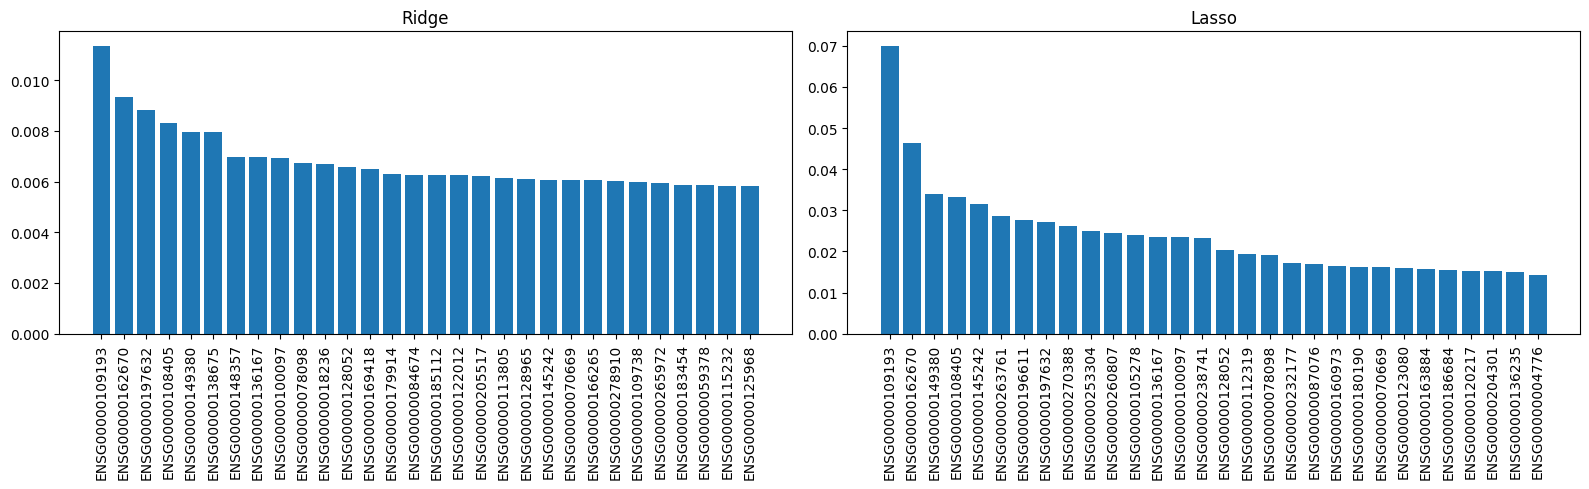

In [6]:
# ===== Cell 6: feature importance — Ridge vs Lasso (|coef|) =====
imp_dfs = {}
for name, coef_arr in [("Ridge", ridge_coef_abs), ("Lasso", lasso_coef_abs)]:
    df = (
        pd.DataFrame({"gene": GENE_COLS, "importance": coef_arr.mean(axis=0)})
        .sort_values("importance", ascending=False).reset_index(drop=True)
    )
    imp_dfs[name] = df
    total = df["importance"].sum()
    top1  = df["importance"].iloc[0]  / total
    top5  = df["importance"].iloc[:5].sum()  / total
    top20 = df["importance"].iloc[:20].sum() / total
    n_nonzero = (df["importance"] > 1e-8).sum()
    print(f"{name}: top1={top1:.1%} | top5={top5:.1%} | top20={top20:.1%} | nonzero_features={n_nonzero}/{len(df)}")
    print(df.head(10))
    print()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, name in zip(axes, ["Ridge", "Lasso"]):
    df = imp_dfs[name]
    ax.bar(range(30), df["importance"].iloc[:30])
    ax.set_xticks(range(30)); ax.set_xticklabels(df["gene"].iloc[:30], rotation=90)
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [7]:
# ===== diagnostic: check actual coefficient magnitudes =====
lasso_raw = lasso_coef_abs.mean(axis=0)  # same values feeding imp_dfs["Lasso"]

print("min:", lasso_raw.min())
print("max:", lasso_raw.max())
print("mean:", lasso_raw.mean())
print("\npercentiles:")
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"  {p}th: {np.percentile(lasso_raw, p):.2e}")

print("\ntop 20 raw values (not %):")
print(np.sort(lasso_raw)[::-1][:20])

print("\ncount > 0 exactly:", (lasso_raw > 0).sum())
print("count > 1e-8:", (lasso_raw > 1e-8).sum())
print("count > 1e-6:", (lasso_raw > 1e-6).sum())
print("count > 1e-4:", (lasso_raw > 1e-4).sum())

min: 0.0
max: 0.07001433366288741
mean: 0.0005333418714738703

percentiles:
  50th: 0.00e+00
  75th: 0.00e+00
  90th: 3.56e-04
  95th: 3.31e-03
  99th: 1.18e-02
  99.9th: 2.86e-02

top 20 raw values (not %):
[0.07001433 0.04642634 0.03384274 0.03318373 0.03150147 0.02861069
 0.02757981 0.02709365 0.02628649 0.02494072 0.02454306 0.02402323
 0.02338388 0.02338249 0.02333683 0.02027481 0.01941142 0.0192147
 0.01725116 0.01705195]

count > 0 exactly: 542
count > 1e-8: 542
count > 1e-6: 542
count > 1e-4: 531


In [8]:
# ===== corrected: rebuild from the same array you just diagnosed =====
lasso_df_fixed = (
    pd.DataFrame({"gene": GENE_COLS, "importance": lasso_raw})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

zeroed = lasso_df_fixed[lasso_df_fixed["importance"] <= 1e-8]
kept   = lasso_df_fixed[lasso_df_fixed["importance"] >  1e-8]

print(f"Lasso zeroed {len(zeroed)} / {len(lasso_df_fixed)} genes")
print(f"Lasso kept   {len(kept)} / {len(lasso_df_fixed)} genes\n")

pd.set_option("display.max_rows", None)
print("=== KEPT (nonzero) genes ===")
print(kept[["gene", "importance"]])

Lasso zeroed 4458 / 5000 genes
Lasso kept   542 / 5000 genes

=== KEPT (nonzero) genes ===
                gene  importance
0    ENSG00000109193    0.070014
1    ENSG00000162670    0.046426
2    ENSG00000149380    0.033843
3    ENSG00000108405    0.033184
4    ENSG00000145242    0.031501
5    ENSG00000263761    0.028611
6    ENSG00000196611    0.027580
7    ENSG00000197632    0.027094
8    ENSG00000270388    0.026286
9    ENSG00000253304    0.024941
10   ENSG00000260807    0.024543
11   ENSG00000105278    0.024023
12   ENSG00000136167    0.023384
13   ENSG00000100097    0.023382
14   ENSG00000238741    0.023337
15   ENSG00000128052    0.020275
16   ENSG00000112319    0.019411
17   ENSG00000078098    0.019215
18   ENSG00000232177    0.017251
19   ENSG00000087076    0.017052
20   ENSG00000160973    0.016352
21   ENSG00000180190    0.016311
22   ENSG00000070669    0.016205
23   ENSG00000123080    0.015934
24   ENSG00000163884    0.015713
25   ENSG00000186684    0.015394
26   ENSG000001202

In [9]:
# ===== Cell 7: Ridge restricted to Lasso's non-zero features =====
kept_genes = kept["gene"].tolist()
gene_idx   = [GENE_COLS.index(g) for g in kept_genes]
X_selected = X[:, gene_idx]   # X already has CPM+log1p applied from Cell 3
print("features used:", X_selected.shape[1], "(down from", X.shape[1], ")")

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_true           = np.zeros(len(y), dtype=int)
oof_pred_ridge_sel = np.zeros(len(y), dtype=int)
ridge_sel_coef_abs = np.zeros((N_SPLITS, X_selected.shape[1]))

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_selected, y, groups)):
    X_tr_raw, X_te_raw = X_selected[train_idx], X_selected[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    test_groups = np.unique(groups[test_idx])

    scaler = StandardScaler().fit(X_tr_raw)
    X_tr = scaler.transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    ridge = LogisticRegression(
        penalty="l2", C=1.0, solver="saga", class_weight="balanced",
        max_iter=MAX_ITER, tol=1e-4, random_state=SEED
    )
    ridge.fit(X_tr, y_tr)
    oof_pred_ridge_sel[test_idx] = ridge.predict(X_te)
    ridge_sel_coef_abs[fold] = np.abs(ridge.coef_).mean(axis=0)

    oof_true[test_idx] = y_te
    print(f"fold {fold} | test studies: {list(test_groups)} | n_test={len(test_idx)} | ridge_iters={ridge.n_iter_}")

acc = accuracy_score(oof_true, oof_pred_ridge_sel)
f1  = f1_score(oof_true, oof_pred_ridge_sel, average="macro", zero_division=0)
print(f"\n--- Ridge on Lasso-selected features (n={X_selected.shape[1]}): overall ---")
print(f"accuracy: {acc:.4f} | macro_f1: {f1:.4f}")
print(classification_report(oof_true, oof_pred_ridge_sel, target_names=CLASSES, zero_division=0))

features used: 542 (down from 5000 )
fold 0 | test studies: ['GSE122380', 'GSE141910'] | n_test=463 | ridge_iters=[2260]
fold 1 | test studies: ['GSE131236', 'GSE239918', 'GSE85331,GSE85332'] | n_test=28 | ridge_iters=[1384]
fold 2 | test studies: ['GSE117192', 'GTEx'] | n_test=48 | ridge_iters=[1973]

--- Ridge on Lasso-selected features (n=542): overall ---
accuracy: 1.0000 | macro_f1: 1.0000
              precision    recall  f1-score   support

       Adult       1.00      1.00      1.00       170
   Embryonic       1.00      1.00      1.00       313
    Maturing       1.00      1.00      1.00        56

    accuracy                           1.00       539
   macro avg       1.00      1.00      1.00       539
weighted avg       1.00      1.00      1.00       539



In [11]:
# ===== Cell 7 (nested, no leakage): select top-100 via Lasso INSIDE each fold =====
top_n = 100

sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_true      = np.zeros(len(y), dtype=int)
oof_pred_nest = np.zeros(len(y), dtype=int)
fold_selected_genes = []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    X_tr_raw, X_te_raw = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    test_groups = np.unique(groups[test_idx])

    scaler = StandardScaler().fit(X_tr_raw)
    X_tr = scaler.transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)

    # -- feature selection using ONLY this fold's training data --
    lasso = LogisticRegression(
        penalty="l1", C=1.0, solver="saga", class_weight="balanced",
        max_iter=MAX_ITER, tol=1e-4, random_state=SEED
    )
    lasso.fit(X_tr, y_tr)
    fold_imp = np.abs(lasso.coef_).mean(axis=0)
    top_idx_fold = np.argsort(fold_imp)[::-1][:top_n]
    fold_selected_genes.append([GENE_COLS[i] for i in top_idx_fold])

    # -- Ridge trained/evaluated ONLY on genes selected from this fold's train split --
    ridge = LogisticRegression(
        penalty="l2", C=1.0, solver="saga", class_weight="balanced",
        max_iter=MAX_ITER, tol=1e-4, random_state=SEED
    )
    ridge.fit(X_tr[:, top_idx_fold], y_tr)
    oof_pred_nest[test_idx] = ridge.predict(X_te[:, top_idx_fold])
    oof_true[test_idx] = y_te
    print(f"fold {fold} | test studies: {list(test_groups)} | n_test={len(test_idx)}")

acc = accuracy_score(oof_true, oof_pred_nest)
f1  = f1_score(oof_true, oof_pred_nest, average="macro", zero_division=0)
print(f"\n--- Ridge, nested Lasso-top-{top_n} per fold (no selection leakage): overall ---")
print(f"accuracy: {acc:.4f} | macro_f1: {f1:.4f}")

print("\ngenes selected per fold (check overlap):")
for i, genes in enumerate(fold_selected_genes):
    print(f"fold {i}: {genes[:10]} ...")

fold 0 | test studies: ['GSE122380', 'GSE141910'] | n_test=463
fold 1 | test studies: ['GSE131236', 'GSE239918', 'GSE85331,GSE85332'] | n_test=28
fold 2 | test studies: ['GSE117192', 'GTEx'] | n_test=48

--- Ridge, nested Lasso-top-100 per fold (no selection leakage): overall ---
accuracy: 0.9759 | macro_f1: 0.9547

genes selected per fold (check overlap):
fold 0: ['ENSG00000160973', 'ENSG00000128052', 'ENSG00000163884', 'ENSG00000110786', 'ENSG00000196367', 'ENSG00000162551', 'ENSG00000147041', 'ENSG00000168671', 'ENSG00000164023', 'ENSG00000010610'] ...
fold 1: ['ENSG00000149380', 'ENSG00000145242', 'ENSG00000263761', 'ENSG00000196611', 'ENSG00000270388', 'ENSG00000197632', 'ENSG00000232177', 'ENSG00000120217', 'ENSG00000136235', 'ENSG00000196639'] ...
fold 2: ['ENSG00000109193', 'ENSG00000162670', 'ENSG00000253304', 'ENSG00000238741', 'ENSG00000087076', 'ENSG00000108405', 'ENSG00000070669', 'ENSG00000112319', 'ENSG00000123080', 'ENSG00000004776'] ...
